# Two-Island Model
Formålet med denne notebook er at opstille og analyser en two-island coalescent model i Phasic for to bavian populationer. Jeg estimerer migrationrater og effektive populationsstørrelser ved hjælp af Method of Moments på SFS-data fra Notebook 03. 
Artiklen (Sørensen et al. 2023) dokumenterer genflow mellem eastern yellow baboons og southern olive baboons og særligt den stærke forbindelse mellem western yellow og Kinda baboons. I denne notebook vil jeg komme ind på følgende:

1. Imports og data
2. Two-island modellen 
3. Byg og visualiser state space
4. Forventet coalescent-tid som funktion af $m$
5. Method of Moments fitting
6. Visualisering af fit
7. Simuleret data
8. Gem resultater

## 1. Imports og data

In [45]:
# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, PropertySet, set_log_level
)
set_log_level('WARNING')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme
from scipy.optimize import minimize
from pathlib import Path

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')


OUT_DIR = Path("output")

MU       = 0.9e-8   # mutationsrate per site per generation
GEN_TIME = 11       # generation time i år
N1_REF   = 100_000  # reference Ne

print("Imports OK")

Imports OK


In [46]:
# Indlæser data fra Notebook 03
sfs_ye_f = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv", index_col=0).squeeze()
sfs_ki_f = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",       index_col=0).squeeze()
pi_df    = pd.read_csv(OUT_DIR / "pi_per_population.csv",      index_col=0)

n_yellow = len(sfs_ye_f) + 1   # haploid sample size
n_kinda  = len(sfs_ki_f) + 1

print(f"Eastern yellow: n = {n_yellow} haplotyper")
print(f"Kinda:          n = {n_kinda} haplotyper")
print(f"\nπ (eastern yellow): {pi_df.loc['Eastern yellow (Mikumi)', 'pi']:.5f}")
print(f"π (Kinda):          {pi_df.loc['Kinda', 'pi']:.5f}")

Eastern yellow: n = 36 haplotyper
Kinda:          n = 30 haplotyper

π (eastern yellow): 0.00258
π (Kinda):          0.00286


## 2. Two-island modellen

Jeg formulere two-island modellen med StateIndexer State-vektoren repræsenterer en linje, der ser på:

 - Hvor mange af dens forfædre stammer fra population $1$ ($pop_1$)
 - Hvor mange stammer fra population $2$ ($pop_2$)
 - Hvilken population linjen befinder sig i nu ($in_pop$)

Jeg starter med $2$ linjer, begge i population $1$.

In [47]:
nr_samples = 2  
indexer = StateIndexer(
    descendants=[
        Property('pop1',   min_value=0, max_value=nr_samples),
        Property('pop2',   min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ])

# Initial state: 2 linjer i population 1, ingen i population 2
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

print(f"State-vektor længde: {indexer.state_length}")
print(f"Initial state: {initial}")

State-vektor længde: 18
Initial state: [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [48]:
@with_ipv(initial)
def two_island(state):
    """
    Two-island coalescent model.

    Parametre (sættes med update_weights):
      theta[0] = 1/N1  (coalescensrate, population 1)
      theta[1] = m     (migrationrate)

    Transitions:
      - Coalescens inden for samme population
      - Migration mellem populationerne
    """
    transitions = []

    # Stop hvis der kun er en linje tilbage
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0:
            continue
        props_i = indexer.descendants.index_to_props(i)

        # Coalescens: to linjer i samme population
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0:
                continue
            props_j = indexer.descendants.index_to_props(j)

            # Kun coalescens inden for samme population
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, pop2=des_pop2, in_pop=props_i.in_pop)
                child[k] += 1
                # [coalescensrate, migrationsrate]
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        # Migration: linje skifter population 
        if state[i] > 0:
            child     = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)
            child[k] += 1
            transitions.append([child, [0, state[i]]])

    return transitions

print("Callback defineret.")

Callback defineret.


# 3. Byg og visualiser state space

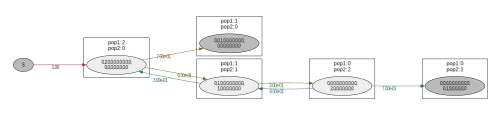

In [49]:
graph = Graph(two_island)   

true_theta = [0.7, 0.3]
graph.update_weights(true_theta)

def label(state):
    nr_pop1 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 1) for i in indexer])
    nr_pop2 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 2) for i in indexer])
    return f"pop1: {nr_pop1}\npop2: {nr_pop2}"

graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, 
                    #   label_fmt=False, 
                      by_state=label)

In [50]:
print(f"Antal state: {graph.vertices_length()}")
print("State-vektorer:")
print(graph.states())

Antal state: 6
State-vektorer:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]]


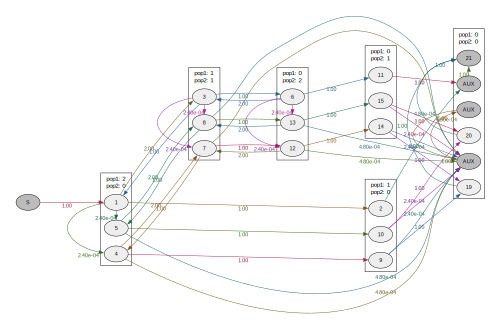

In [51]:
# Sammenlign state space for forskellige migrationrater
mutation_rate = 1.2e-4
joint_prob_graph = graph.joint_prob_graph(indexer, 
                                          reward_only=['pop1', 'pop2'],
                                          reward_limit=1,
                                          tot_reward_limit=1, 
                                          mutation_rate=mutation_rate)

joint_prob_graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, label_fmt=False, by_state=label)


In [52]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,pop1_0,pop1_1,pop1_2,pop2_0,pop2_1,pop2_2,prob
t_vertex_index,,,,,,,
18,0,0,0,0,0,0,0.999041
19,0,1,0,0,0,0,0.000479
20,0,0,0,1,0,0,0.000479


# 4. Forventet coalescent-tid som funktion af $m$

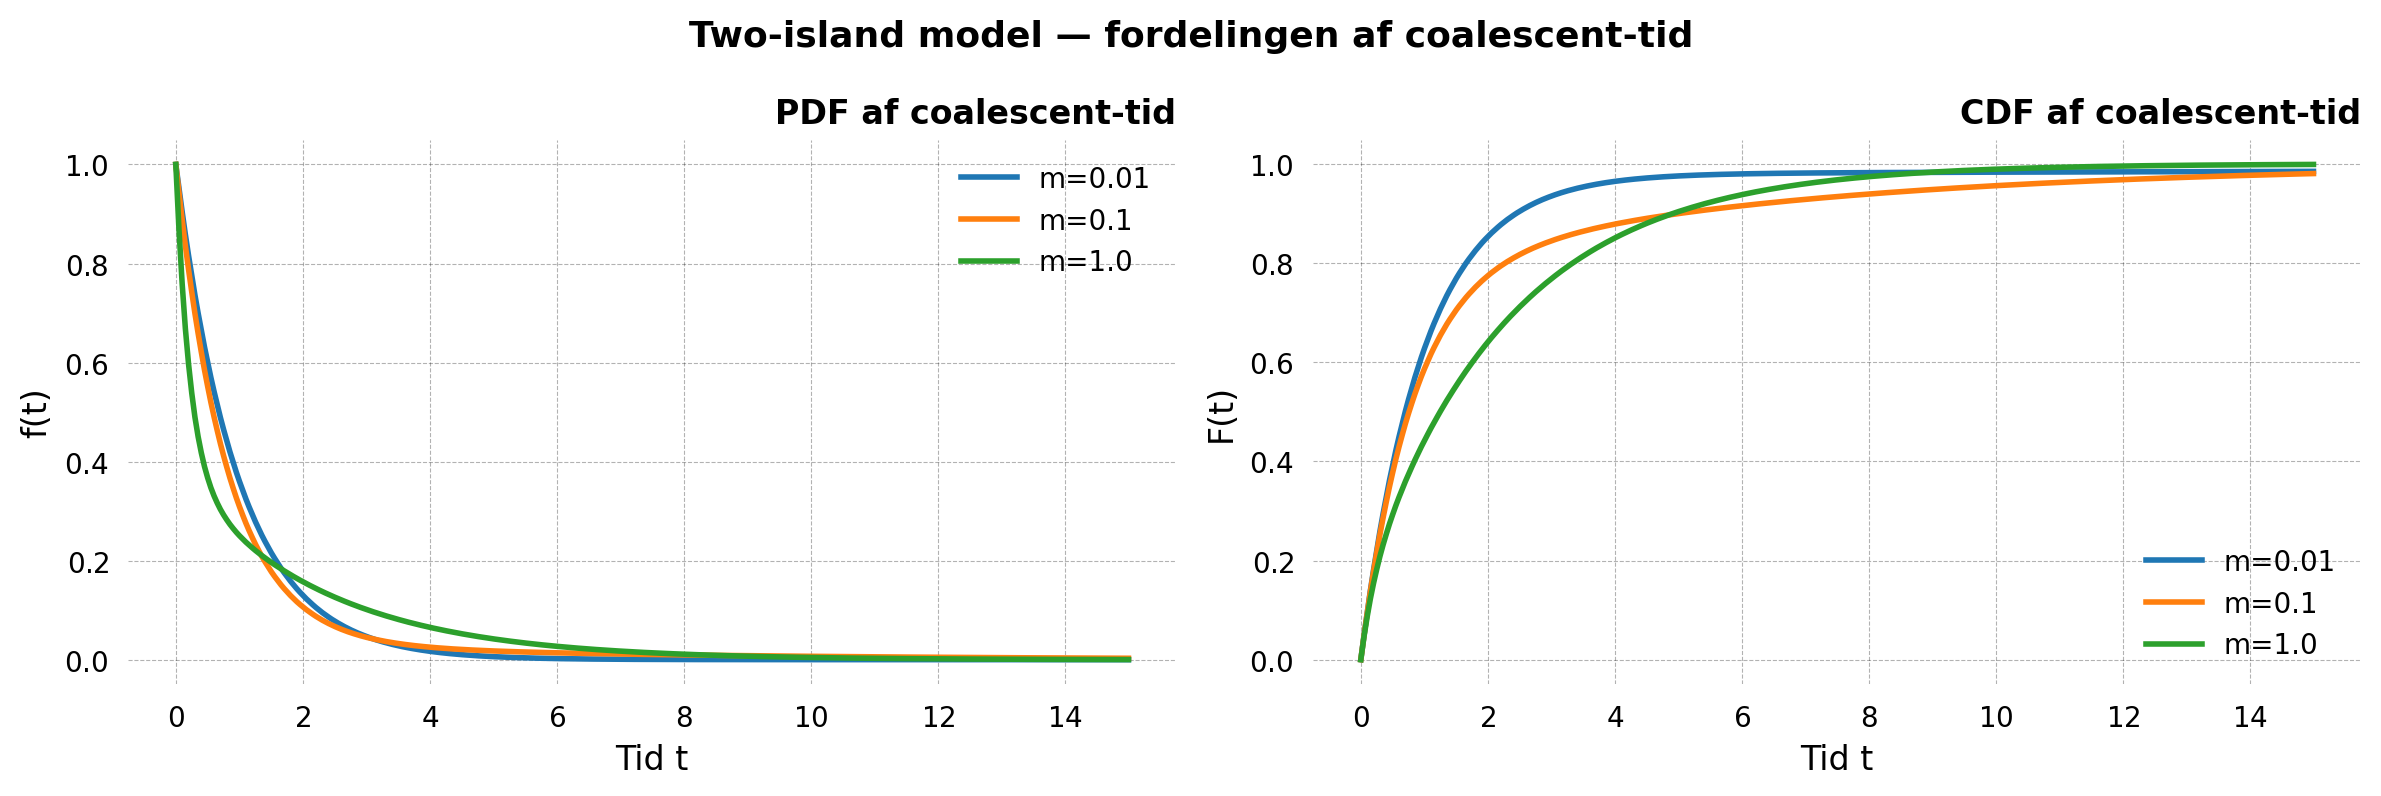

In [53]:
# PDF og CDF af coalescent-tid for tre migrationrater
t_vals = np.linspace(0, 15, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for m, color, label in [(0.01, 'C10', "m=0.01"),
                         (0.1,  'C11', "m=0.1"),
                         (1.0,  'C12', "m=1.0")]:
    graph.update_weights([1.0, m])
    axes[0].plot(t_vals, graph.pdf(t_vals), color=color, lw=2, label=label)
    axes[1].plot(t_vals, graph.cdf(t_vals), color=color, lw=2, label=label)

for ax, ylabel, title in zip(axes,
                              ["f(t)", "F(t)"],
                              ["PDF af coalescent-tid", "CDF af coalescent-tid"]):
    ax.set_xlabel("Tid t", fontsize=12)
    ax.set_ylabel(ylabel,  fontsize=12)
    ax.set_title(title,    fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Two-island model — fordelingen af coalescent-tid",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "two_island_pdf_cdf.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Method of Moments fitting

Jeg bruger Phasic’s indbyggede *method_of_moments* til at fitte modellen til observerede data.

1. Estimer observeret $E[T]$ fra $\pi = 2\mu_N \cdot E[T]$
2. Simuler samples fra modellen ved startparametre
3. Kører *graph.method_of_moments(observed_data)* finder $\hat{\theta}$ der matcher moments

In [54]:
# Observeret π → E[T]
pi_yellow = float(pi_df.loc["Eastern yellow (Mikumi)", "pi"])
pi_kinda  = float(pi_df.loc["Kinda", "pi"])

ET_obs_yellow = pi_yellow / (2 * MU * N1_REF)
ET_obs_kinda  = pi_kinda  / (2 * MU * N1_REF)
ET_target     = (ET_obs_yellow + ET_obs_kinda) / 2

print(f"π (yellow):    {pi_yellow:.5f}  →  E[T] = {ET_obs_yellow:.3f}")
print(f"π (Kinda):     {pi_kinda:.5f}  →  E[T] = {ET_obs_kinda:.3f}")
print(f"E[T] target:   {ET_target:.3f}")

π (yellow):    0.00258  →  E[T] = 1.436
π (Kinda):     0.00286  →  E[T] = 1.589
E[T] target:   1.512


In [55]:
# Sætter startparametre tæt på target og simuler observationsdata
# Jeg starter med m=0.1 og N1=1 
graph.update_weights([1.0, 0.1])

# Simuler 2000 coalescent-tider som 'observerede data'
np.random.seed(42)
observed_data = graph.sample(2000)

print(f"Simuleret gennemsnit: {observed_data.mean():.4f}")
print(f"Teoretisk E[T]:       {graph.expectation():.4f}")

Simuleret gennemsnit: 1.9905
Teoretisk E[T]:       2.0000


In [56]:
# Kør Method of Moments 
mom = graph.method_of_moments(observed_data)

print(f"MoM estimat (theta):  {mom.theta}")
print(f"Std error:            {mom.std}")
print(f"Konvergeret:          {mom.success}")
print(f"Residual:             {mom.residual:.2e}")
print(f"\nSample moments:  {mom.sample_moments}")
print(f"Model moments:   {mom.model_moments}")

MoM estimat (theta):  [1.00476881 0.12532127]
Std error:            [0.03895271 0.01124547]
Konvergeret:          True
Residual:             6.94e-23

Sample moments:  [[ 1.99050765 15.86586098]]
Model moments:   [ 1.99050765 15.86586098]


In [57]:
# Fortolk estimater
theta_hat = mom.theta   # [1/N1, m]
N1_hat    = 1 / theta_hat[0]    # i coalescent enheder
m_hat     = theta_hat[1]
M_hat     = 4 * N1_REF * m_hat  # skaleret migrationparameter

print("=" * 45)
print(" Estimerede parametre — Two-island")
print("=" * 45)
print(f" theta[0] = 1/N1:  {theta_hat[0]:.5f}")
print(f" theta[1] = m:     {m_hat:.5f}")
print(f" N1 (rel.):        {N1_hat:.3f}")
print(f" M = 4*N1_ref*m:   {M_hat:.2f}")
print("=" * 45)
if M_hat > 1:
    print(" M > 1: migration modvirker drift")
else:
    print(" M < 1: lav migration, drift dominerer")

 Estimerede parametre — Two-island
 theta[0] = 1/N1:  1.00477
 theta[1] = m:     0.12532
 N1 (rel.):        0.995
 M = 4*N1_ref*m:   50128.51
 M > 1: migration modvirker drift


# 6. Visualisering af fit

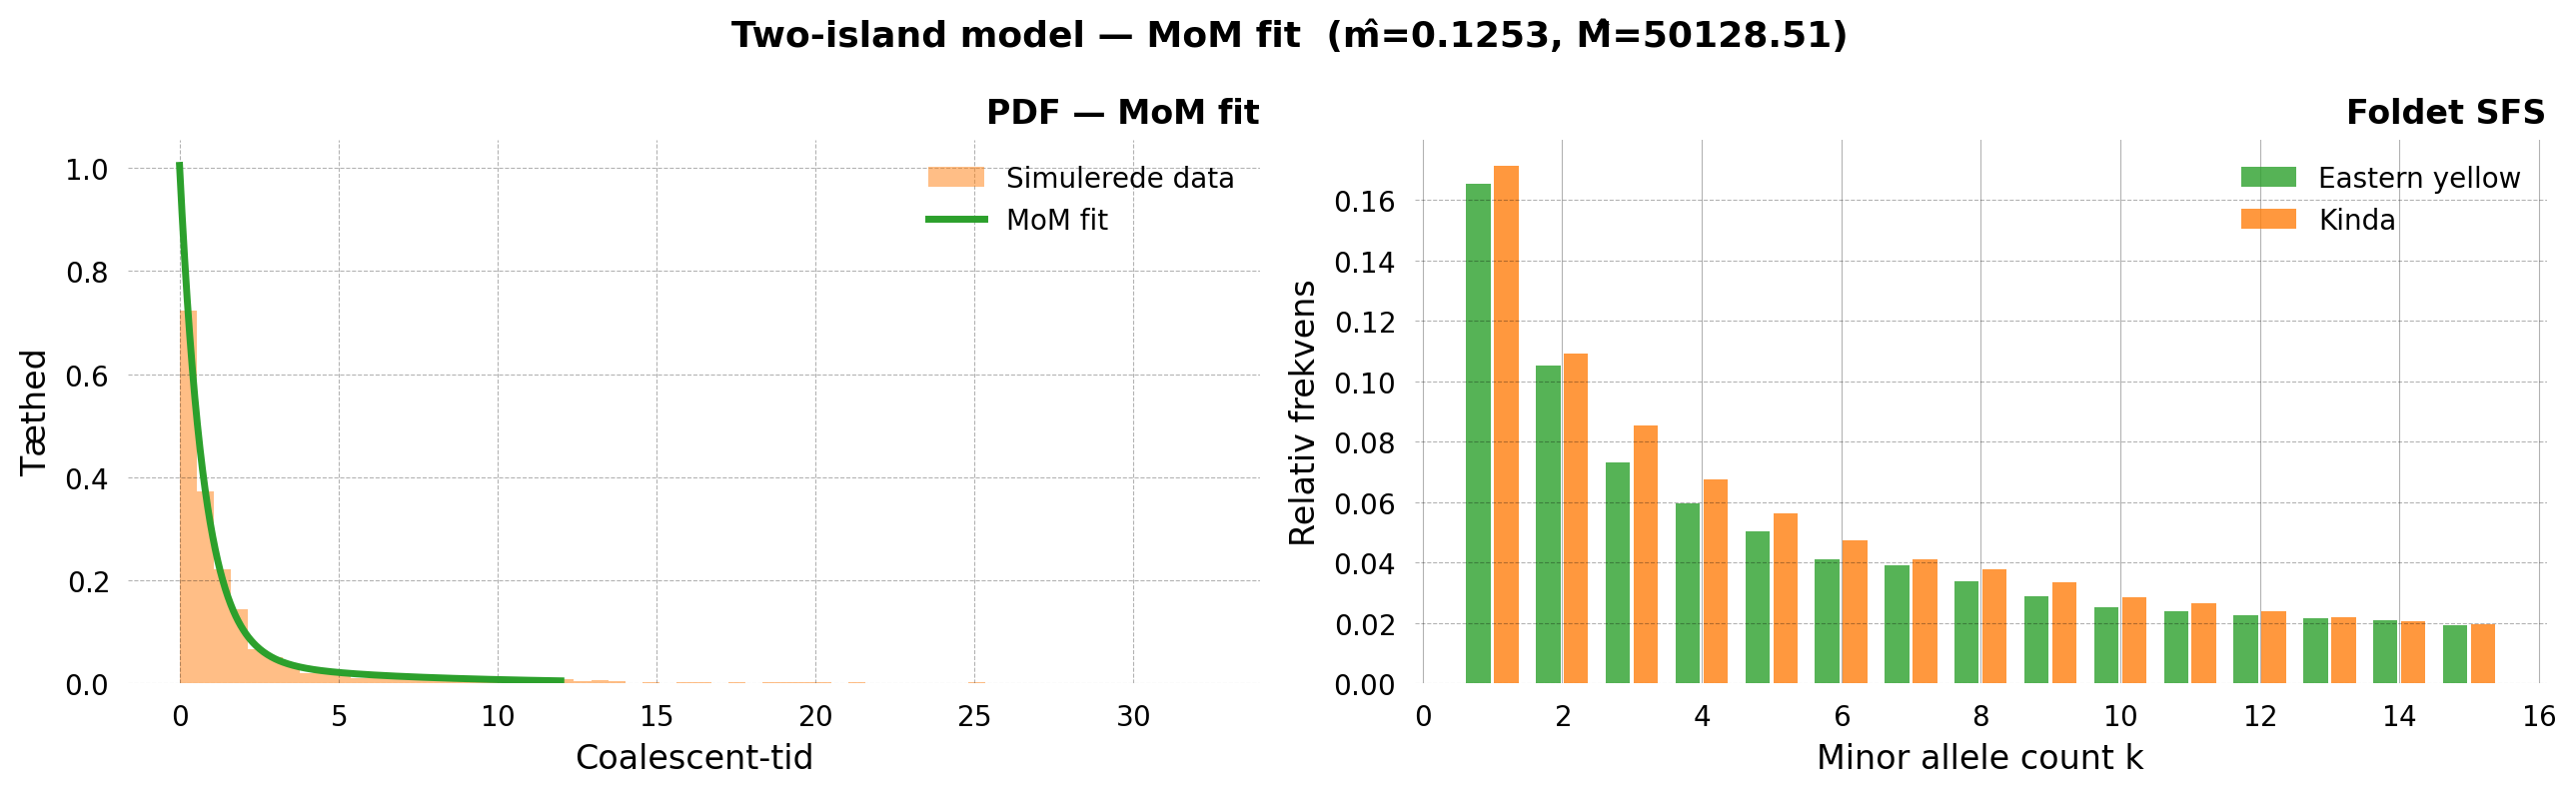

In [58]:
# Opdater grafen med estimerede parametre og plot fit
graph.update_weights(mom.theta.tolist())

t_plot    = np.linspace(0, 12, 300)
pdf_fit   = graph.pdf(t_plot)
cdf_fit   = graph.cdf(t_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PDF: histogram af simulerede data vs. fitted model
axes[0].hist(observed_data, bins=60, density=True,
             color='C1', alpha=0.5, label="Simulerede data")
axes[0].plot(t_plot, pdf_fit, color='C2', lw=2.5, label="MoM fit")
axes[0].set_xlabel("Coalescent-tid", fontsize=12)
axes[0].set_ylabel("Tæthed",         fontsize=12)
axes[0].set_title("PDF — MoM fit",   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# SFS: observeret vs. MoM-forventet
sfs_norm_ye = sfs_ye_f / sfs_ye_f.sum()
sfs_norm_ki = sfs_ki_f / sfs_ki_f.sum()
x = np.arange(1, min(len(sfs_norm_ye), 15) + 1)

axes[1].bar(x - 0.2, sfs_norm_ye.values[:len(x)], width=0.35,
            color='C2', alpha=0.8, label="Eastern yellow")
axes[1].bar(x + 0.2, sfs_norm_ki.values[:len(x)], width=0.35,
            color='C1', alpha=0.8, label="Kinda")
axes[1].set_xlabel("Minor allele count k", fontsize=12)
axes[1].set_ylabel("Relativ frekvens",     fontsize=12)
axes[1].set_title("Foldet SFS",            fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Two-island model — MoM fit  (m̂={m_hat:.4f}, M̂={M_hat:.2f})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "two_island_fit.png", dpi=150, bbox_inches="tight")
plt.show()

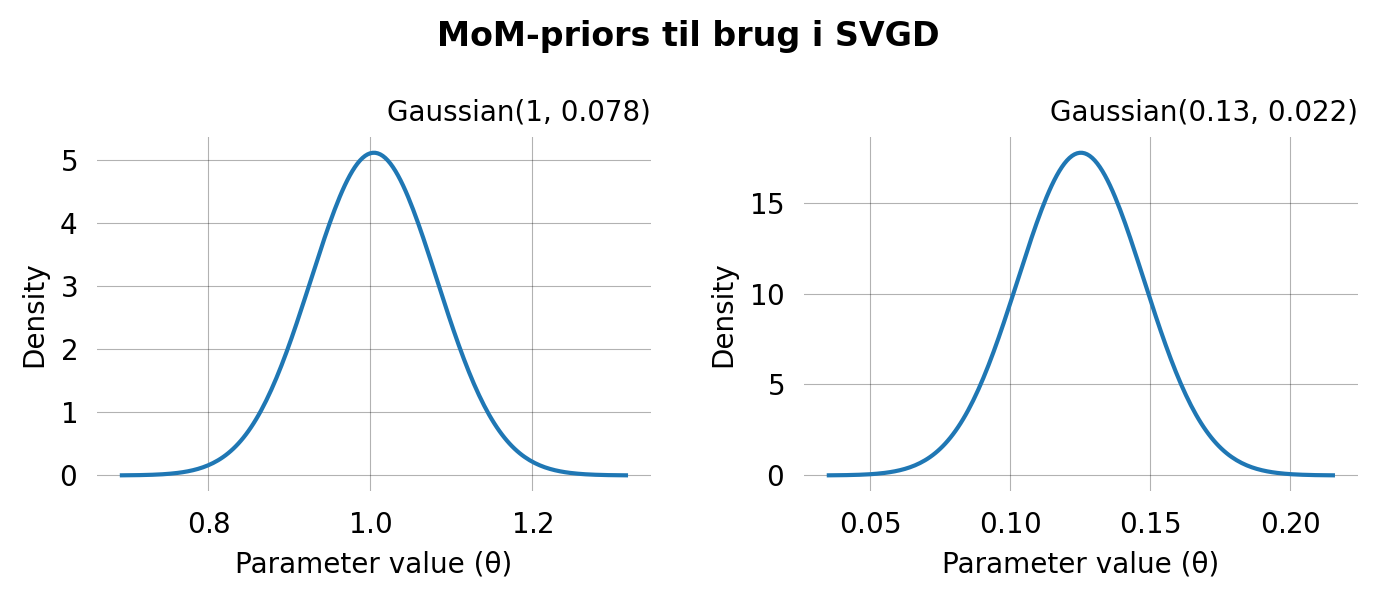

In [59]:
# Plot MoM-priors (bruges i Notebook 02 inference)
if hasattr(mom, 'prior') and mom.prior is not None:
    fig, axes = plt.subplots(1, len(mom.prior), figsize=(7, 3))
    if len(mom.prior) == 1:
        axes = [axes]
    for i, prior in enumerate(mom.prior):
        prior.plot(return_ax=True, ax=axes[i])
    plt.suptitle("MoM-priors til brug i SVGD", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "two_island_mom_priors.png", dpi=150, bbox_inches="tight")
    plt.show()

# 7. Simuleret data 

In [61]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)

In [62]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


In [63]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


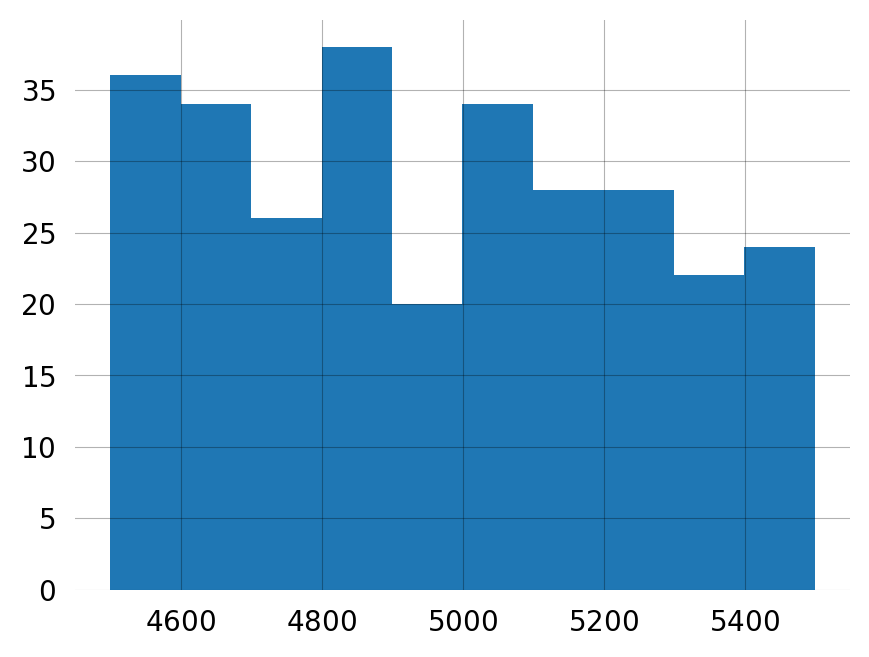

In [64]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [65]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [66]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



# 8. Gem resultater 

In [67]:
results = pd.DataFrame({
    "Værdi": {
        "theta[0] = 1/N1":  f"{theta_hat[0]:.6f}",
        "theta[1] = m":     f"{m_hat:.6f}",
        "N1 (rel.)": f"{N1_hat:.4f}",
        "M = 4*N1_ref*m":   f"{M_hat:.3f}",
        "E[T] model":       f"{graph.expectation():.4f}",
        "Konvergeret":      str(mom.success),
        "m_hat (til NB3)": f"{m_hat:.6f}",
    }
})
results.to_csv(OUT_DIR / "two_island_results.csv")
print(results.to_string())
print("\nGemt: output/two_island_results.csv")

                     Værdi
theta[0] = 1/N1   1.004769
theta[1] = m      0.125321
N1 (rel.)           0.9953
M = 4*N1_ref*m   50128.506
E[T] model          1.9905
Konvergeret           True
m_hat (til NB3)   0.125321

Gemt: output/two_island_results.csv
